# 07_transformer

In [41]:
import pickle
import numpy as np
from pathlib import Path
from torch.utils.data import DataLoader
import sys
sys.path.append(r"D:\360Downloads\bioinformatics\Task\AIP")
from src.dataset_transformer import ResidueFusionDataset, collate_fn

In [42]:
PROJECT_ROOT = Path.cwd().parent.parent

prott5_dir = PROJECT_ROOT / "data" / "processed" / "prott5_residue"
esm2_dir = PROJECT_ROOT / "data" / "processed" / "esm2_residue"

with open(prott5_dir / "X_train_prott5_residue.pkl", "rb") as f:
    X_train_prott5 = pickle.load(f)

with open(prott5_dir / "X_test_prott5_residue.pkl", "rb") as f:
    X_test_prott5 = pickle.load(f)

with open(esm2_dir / "X_train_esm2_residue.pkl", "rb") as f:
    X_train_esm2 = pickle.load(f)

with open(esm2_dir / "X_test_esm2_residue.pkl", "rb") as f:
    X_test_esm2 = pickle.load(f)

y_train = np.load(prott5_dir / "y_train.npy")
y_test = np.load(prott5_dir / "y_test.npy")

In [43]:
train_dataset = ResidueFusionDataset(X_train_prott5, X_train_esm2, y_train)
test_dataset = ResidueFusionDataset(X_test_prott5, X_test_esm2, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn
)

In [44]:
batch = next(iter(train_loader))
print(batch["prott5"].shape)
print(batch["esm2"].shape)
print(batch["attention_mask"].shape)
print(batch["label"].shape)

torch.Size([32, 24, 768])
torch.Size([32, 24, 480])
torch.Size([32, 24])
torch.Size([32, 1])


In [45]:
import torch
torch.Size([32, 30, 768])
torch.Size([32, 30, 480])
torch.Size([32, 30])
torch.Size([32, 1])

torch.Size([32, 1])

In [46]:
from src.transformer_model import ResidueFusionTransformer

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

prott5_dim = batch["prott5"].shape[-1]
esm2_dim = batch["esm2"].shape[-1]

model = ResidueFusionTransformer(
    prott5_dim=prott5_dim,
    esm2_dim=esm2_dim,
    d_model=128,
    nhead=4,
    num_layers=2,
    dim_feedforward=256,
    dropout=0.2
).to(device)

with torch.no_grad():
    logits = model(
        batch["prott5"].to(device),
        batch["esm2"].to(device),
        batch["attention_mask"].to(device)
    )

print("logits shape:", logits.shape)

device: cpu
logits shape: torch.Size([32, 1])


In [47]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, roc_auc_score, average_precision_score
)

def compute_metrics(y_true, y_pred, y_prob):
    return {
        "ACC": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "PR_AUC": average_precision_score(y_true, y_prob)
    }

In [48]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for batch in loader:
        prott5_x = batch["prott5"].to(device)
        esm2_x = batch["esm2"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        logits = model(prott5_x, esm2_x, attention_mask)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)

    return running_loss / len(loader.dataset)

In [49]:
import numpy as np
import torch

def evaluate_on_loader(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in loader:
            prott5_x = batch["prott5"].to(device)
            esm2_x = batch["esm2"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            logits = model(prott5_x, esm2_x, attention_mask)
            loss = criterion(logits, labels)

            probs = torch.sigmoid(logits)

            running_loss += loss.item() * labels.size(0)

            all_labels.extend(labels.cpu().numpy().ravel())
            all_probs.extend(probs.cpu().numpy().ravel())

    avg_loss = running_loss / len(loader.dataset)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    all_preds = (all_probs >= 0.5).astype(int)

    metrics = compute_metrics(all_labels, all_preds, all_probs)
    return avg_loss, metrics, all_labels, all_preds, all_probs

In [50]:
from sklearn.model_selection import train_test_split

train_idx, val_idx = train_test_split(
    np.arange(len(y_train)),
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

X_tr_prott5 = [X_train_prott5[i] for i in train_idx]
X_val_prott5 = [X_train_prott5[i] for i in val_idx]

X_tr_esm2 = [X_train_esm2[i] for i in train_idx]
X_val_esm2 = [X_train_esm2[i] for i in val_idx]

y_tr = y_train[train_idx]
y_val = y_train[val_idx]

In [51]:
from torch.utils.data import DataLoader

train_dataset = ResidueFusionDataset(X_tr_prott5, X_tr_esm2, y_tr)
val_dataset = ResidueFusionDataset(X_val_prott5, X_val_esm2, y_val)
test_dataset = ResidueFusionDataset(X_test_prott5, X_test_esm2, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

In [81]:
import copy
import torch.nn as nn
import torch.optim as optim

device = "cuda" if torch.cuda.is_available() else "cpu"

model = ResidueFusionTransformer(
    prott5_dim=prott5_dim,
    esm2_dim=esm2_dim,
    d_model=128,
    nhead=4,
    num_layers=2,
    dim_feedforward=256,
    dropout=0.2
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)

In [82]:
num_epochs = 30
best_val_auc = -1
best_model_state = None

history = {
    "train_loss": [],
    "val_loss": [],
    "val_auc": []
}


for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_metrics, _, _, _ = evaluate_on_loader(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_auc"].append(val_metrics["ROC_AUC"])

    print(f"Epoch {epoch:02d}")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val Loss:   {val_loss:.4f}")
    print(f"  Val AUC:    {val_metrics['ROC_AUC']:.4f}")
    print(f"  Val F1:     {val_metrics['F1']:.4f}")
    print(f"  Val MCC:    {val_metrics['MCC']:.4f}")

    if val_metrics["ROC_AUC"] > best_val_auc:
        best_val_auc = val_metrics["ROC_AUC"]
        best_model_state = copy.deepcopy(model.state_dict())

Epoch 01
  Train Loss: 0.6361
  Val Loss:   0.6175
  Val AUC:    0.7196
  Val F1:     0.5044
  Val MCC:    0.3042
Epoch 02
  Train Loss: 0.6058
  Val Loss:   0.6289
  Val AUC:    0.7071
  Val F1:     0.4674
  Val MCC:    0.2590
Epoch 03
  Train Loss: 0.5887
  Val Loss:   0.5705
  Val AUC:    0.7480
  Val F1:     0.6381
  Val MCC:    0.4223
Epoch 04
  Train Loss: 0.5758
  Val Loss:   0.5803
  Val AUC:    0.7440
  Val F1:     0.6367
  Val MCC:    0.4216
Epoch 05
  Train Loss: 0.5611
  Val Loss:   0.5928
  Val AUC:    0.7476
  Val F1:     0.5800
  Val MCC:    0.3955
Epoch 06
  Train Loss: 0.5631
  Val Loss:   0.5821
  Val AUC:    0.7433
  Val F1:     0.6342
  Val MCC:    0.4035
Epoch 07
  Train Loss: 0.5543
  Val Loss:   0.6086
  Val AUC:    0.7451
  Val F1:     0.6391
  Val MCC:    0.4103
Epoch 08
  Train Loss: 0.5488
  Val Loss:   0.5762
  Val AUC:    0.7483
  Val F1:     0.6280
  Val MCC:    0.4070
Epoch 09
  Train Loss: 0.5505
  Val Loss:   0.5741
  Val AUC:    0.7464
  Val F1:     0.

In [83]:
model.load_state_dict(best_model_state)

test_loss, test_metrics, y_true_test, y_pred_test, y_prob_test = evaluate_on_loader(
    model, test_loader, criterion, device
)

print("Test Loss:", round(test_loss, 4))
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

Test Loss: 0.5772
ACC: 0.7224
Precision: 0.6310
Recall: 0.6550
F1: 0.6428
MCC: 0.4161
ROC_AUC: 0.7398
PR_AUC: 0.6245


In [84]:
history["train_loss"]
history["val_loss"]
history["val_auc"]

[0.7196399696399696,
 0.7070999570999571,
 0.7479787479787481,
 0.743969243969244,
 0.7476074976074976,
 0.7432927432927432,
 0.7450664950664951,
 0.7482592482592483,
 0.7464194964194963,
 0.7433711183711185,
 0.7378559878559878,
 0.7309259809259809,
 0.7264132264132264,
 0.7241939741939742,
 0.732988482988483,
 0.7235834735834736,
 0.7218097218097218,
 0.731000231000231,
 0.7184932184932186,
 0.727964227964228,
 0.728129228129228,
 0.7344817344817344,
 0.7326172326172325,
 0.712973962973963,
 0.7133534633534633,
 0.7057634557634557,
 0.6920106920106921,
 0.6934296934296935,
 0.7178332178332179,
 0.6985941985941987]

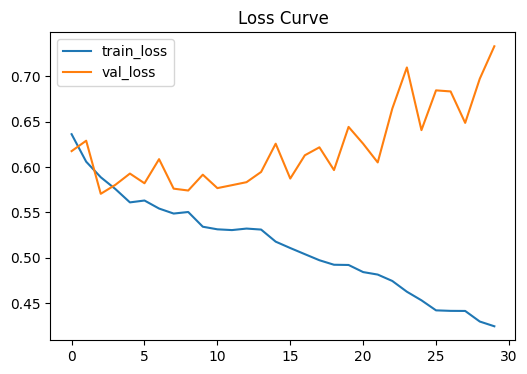

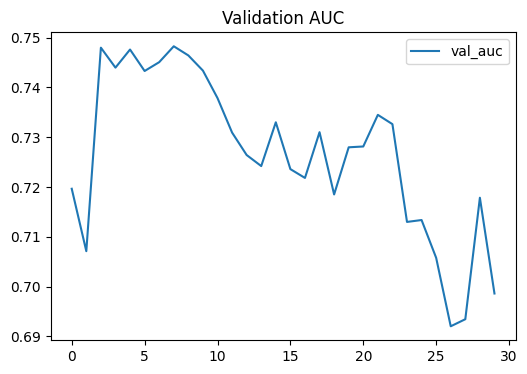

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history["val_auc"], label="val_auc")
plt.legend()
plt.title("Validation AUC")
plt.show()